In [1]:
import json
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import pandas as pd

from src.make_paths_relative_to_root import *

In [2]:
model_name = "dummy"

In [3]:
# Parameters
model_name = "speakleash/Bielik-11B-v2.2-Instruct"


In [4]:
with open("data/edc_baseline/evaluation_results.json", "r") as f:
    metrics = json.load(f)

In [5]:
total_scores = metrics["Total_scores"]

In [6]:
metrics_dict = {}

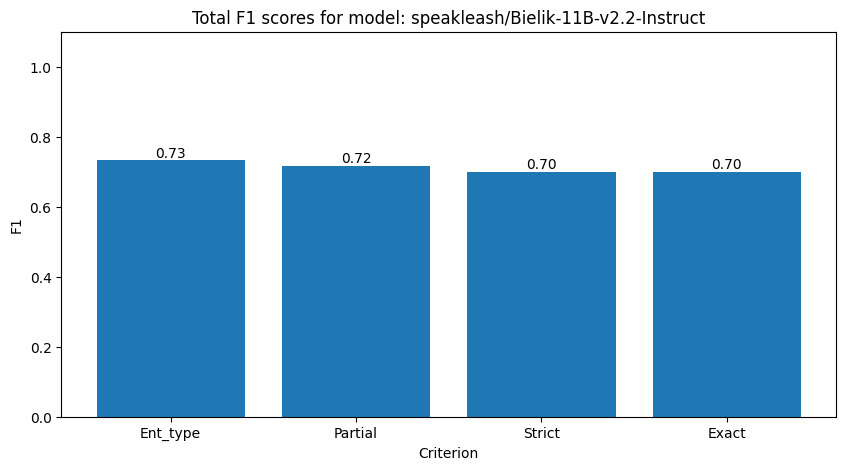

In [7]:
values = [(key, value["F1"]) for key, value in total_scores.items()]
metrics_dict["total_f1"] = {
    **dict(values),
}
plt.figure(figsize=(10, 5))
plt.bar(*zip(*values))
plt.ylim(0, 1.1)
plt.title(f"Total F1 scores for model: {model_name}")
plt.xlabel("Criterion")
plt.ylabel("F1")

# Add text annotations to the bars
for i, (x, y) in enumerate(values):
    plt.text(i, y, f"{y:.2f}", ha="center", va="bottom")

plt.show()

In [8]:
with open("data/edc_baseline/evaluation_results_per_line.json", "r") as f:
    metrics_per_line = json.load(f)

In [9]:
with open("data/edc_baseline/cands.xml", "r") as f:
    cands = f.read()
    # Parse the XML data
    soup = BeautifulSoup(cands, "xml")

    # Extract all gtriple elements
    cands = [gtriple.text for gtriple in soup.find_all("gtriple")]

with open("data/edc_baseline/refs.xml", "r") as f:
    refs = f.read()
    # Parse the XML data
    soup = BeautifulSoup(refs, "xml")

    # Extract all gtriple elements
    refs = [otriple.text for otriple in soup.find_all("otriple")]

In [10]:
df_items = []

for line_idx, line in enumerate(metrics_per_line):
    line = line[0][0]
    ref = refs[line_idx]
    cand = cands[line_idx]
    df_item = {
        "Reference": ref,
        "Candidate": cand,
    }
    for tag in ["SUB", "PRED", "OBJ"]:
        for method in ["ent_type", "strict", "exact", "partial"]:
            metrics = line[tag][method]
            metrics_values = ["correct", "partial", "incorrect", "missed", "spurious"]
            metric_string = ", ".join(
                list(filter(lambda x: metrics[x] > 0, metrics_values))
            )

            df_item[(tag, method)] = metric_string
    df_items.append(df_item)

df = pd.DataFrame(df_items)
pd.set_option("display.max_columns", None)
df

,Reference,Candidate,"(SUB, ent_type)","(SUB, strict)","(SUB, exact)","(SUB, partial)","(PRED, ent_type)","(PRED, strict)","(PRED, exact)","(PRED, partial)","(OBJ, ent_type)","(OBJ, strict)","(OBJ, exact)","(OBJ, partial)"
0,Richard Herd | zawód | Aktor,Richard Herd | zawód | Aktor,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct
1,Saint Clement | lokalizacja | Wyspy Normandzkie,Saint Clement | lokalizacja | Jersey,"correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious"
2,DJ Feel-X | zawód | Producent muzyczny,DJ Feel-X | zawód | Producent muzyczny,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct
3,Sean Kanan | zawód | Aktor,Sean Kanan | zawód | Aktor,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct
4,Hanna Schygulla | zawód | Aktorka,Hanna Schygulla | miejsce urodzenia | Chorzów ...,"correct, spurious","correct, spurious","correct, spurious","correct, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious"
5,Nils Bohlin | zawód | Wynalazca,Nils Bohlin | miejsce urodzenia | Szwecja,"correct, spurious","correct, spurious","correct, spurious","correct, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious"
6,Curtis Armstrong | zawód | Aktor,Curtis Armstrong | zawód | Aktor,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct,correct
7,Alfabet białoruski | typ | Alfabet,Alfabet białoruski | typ | Cyrylica,"correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","correct, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious"
8,Andronik III Paleolog | miejsce urodzenia | Ko...,Andronik III Paleolog | zawód | Cesarz,"correct, spurious","correct, spurious","correct, spurious","correct, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious","missed, spurious"
9,Göran Abrahamsson | miejsce urodzenia | Göteborg,Karl Göran Abrahamsson | miejsce urodzenia | G...,correct,incorrect,incorrect,partial,correct,correct,correct,correct,correct,correct,correct,correct


In [11]:
correct_subjects_mask = df[("SUB", "strict")].str.contains("correct") & (
    ~df[("SUB", "strict")].str.contains("incorrect")
)
partial_subjects_mask = df[("SUB", "partial")].str.contains("partial")

correct_predicates_mask = df[("PRED", "strict")].str.contains("correct") & (
    ~df[("PRED", "strict")].str.contains("incorrect")
)
partial_predicates_mask = df[("PRED", "partial")].str.contains("partial")

correct_objects_mask = df[("OBJ", "strict")].str.contains("correct") & (
    ~df[("OBJ", "strict")].str.contains("incorrect")
)
partial_objects_mask = df[("OBJ", "partial")].str.contains("partial")

In [12]:
subjects_found = len(df[correct_subjects_mask | partial_subjects_mask]) * 100 / len(df)
predicates_found = (
    len(df[correct_predicates_mask | partial_predicates_mask]) * 100 / len(df)
)
objects_found = len(df[correct_objects_mask | partial_objects_mask]) * 100 / len(df)
full_triples_found = (
    len(
        df[
            (correct_subjects_mask | partial_subjects_mask)
            & (correct_predicates_mask | partial_predicates_mask)
            & (correct_objects_mask | partial_objects_mask)
        ]
    )
    * 100
    / len(df)
)

In [13]:
metrics_dict["total_found_strict_or_partial_percent"] = {
    "subjects": subjects_found,
    "predicates": predicates_found,
    "objects": objects_found,
    "full_triples": full_triples_found,
}

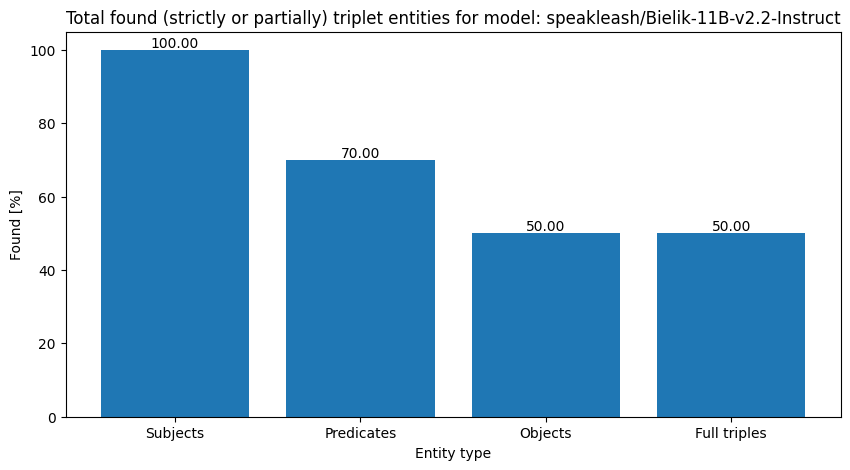

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(
    ["Subjects", "Predicates", "Objects", "Full triples"],
    [subjects_found, predicates_found, objects_found, full_triples_found],
)
plt.title(
    f"Total found (strictly or partially) triplet entities for model: {model_name}"
)
plt.xlabel("Entity type")
plt.ylabel("Found [%]")
# Add text annotations to the bars
for i, (x, y) in enumerate(
    zip(
        ["Subjects", "Predicates", "Objects", "Full triples"],
        [subjects_found, predicates_found, objects_found, full_triples_found],
    )
):
    plt.text(i, y, f"{y:.2f}", ha="center", va="bottom")

plt.show()

In [15]:
metrics_dict

{'total_f1': {'Ent_type': 0.7333333333333333,
  'Partial': 0.7166666666666667,
  'Strict': 0.7,
  'Exact': 0.7},
 'total_found_strict_or_partial_percent': {'subjects': 100.0,
  'predicates': 70.0,
  'objects': 50.0,
  'full_triples': 50.0}}

In [16]:
json.dump(metrics_dict, open("data/edc_baseline/metrics.json", "w"))